In [2]:
import pandas as pd
train= pd.read_csv("data/train.csv")
test= pd.read_csv("data/test.csv")
print(train.shape, test.shape)
print(train.dtypes.value_counts())
missing= train.isnull().sum()
missing=missing[missing > 0]
missing= missing.sort_values(ascending= False)
print(len(missing))
print(missing)
print(train["SalePrice"].describe())

(1460, 81) (1459, 80)
str        43
int64      35
float64     3
Name: count, dtype: int64
19
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


skew before: 1.8828757597682129
skew after: 0.12134661989685333


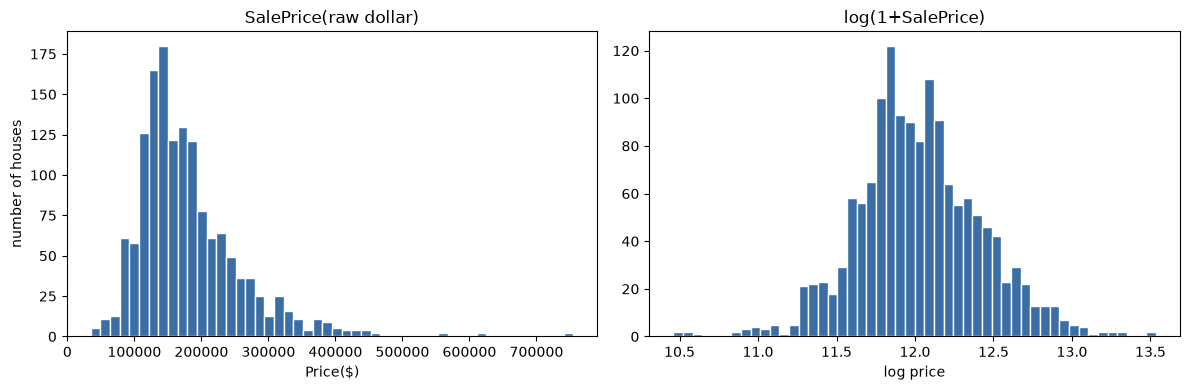

In [3]:
import numpy as np
import matplotlib.pyplot as plt
y_log= np.log1p(train["SalePrice"])
print("skew before:", train["SalePrice"].skew())
print("skew after:", y_log.skew())

fig,axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(train["SalePrice"], bins=50, color= "#3a6ea5", edgecolor= "white")
axes[0].set_title("SalePrice(raw dollar)")
axes[0].set_xlabel("Price($)")
axes[0].set_ylabel("number of houses")

axes[1].hist(y_log, bins=50, color= "#3a6ea5", edgecolor= "white")
axes[1].set_title("log(1+SalePrice)")
axes[1].set_xlabel("log price")
plt.tight_layout()
plt.show()


In [4]:
X= train.drop(columns=["SalePrice", "Id"])
y=np.log1p(train["SalePrice"])
X_test= test.drop(columns=["Id"])

test_ids=test["Id"]

print(X.shape, y.shape, X_test.shape)
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols= X.select_dtypes(exclude= "number").columns.tolist()

print(len(num_cols), "numeric:" , num_cols[:5])
print(len(cat_cols), "categorical:", cat_cols[:5])

(1460, 79) (1460,) (1459, 79)
36 numeric: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond']
43 categorical: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour']


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_pipe= Pipeline([
 ("impute", SimpleImputer(strategy="median"))   
])

cat_pipe= Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output= False)),
])

preprocess= ColumnTransformer([
     ("num", num_pipe, num_cols),
     ("cat", cat_pipe, cat_cols),   
])
X_ready= preprocess.fit_transform(X)
X_test_ready= preprocess.transform(X_test)
print(X_ready.shape, X_test_ready.shape)
print("NaN left:" , np.isnan(X_ready).sum())
print(preprocess.get_feature_names_out()[:3])

(1460, 303) (1459, 303)
NaN left: 0
['num__MSSubClass' 'num__LotFrontage' 'num__LotArea']


In [6]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

kf=KFold(n_splits=5, shuffle=True, random_state=42)
baseline=Pipeline([
    ("prep", preprocess),
    ("model", DummyRegressor(strategy="median")),
])

lin_model= Pipeline([
    ("prep", preprocess),
    ("model", LinearRegression())
])

base_scores= -cross_val_score(baseline, X, y, cv=kf, scoring="neg_root_mean_squared_error")
lin_scores= -cross_val_score(lin_model, X, y, cv=kf, scoring="neg_root_mean_squared_error")

print("Basline RMSE per fold:", base_scores.round(4))
print("Baseline mean +- std", base_scores.mean().round(4), "+-", base_scores.std().round(4))
print("Linear RMSE per fold:", lin_scores.round(4))
print("Linear mean +- std", lin_scores.mean().round(4), "+-", lin_scores.std().round(4))


Basline RMSE per fold: [0.4323 0.3978 0.3782 0.4206 0.3696]
Baseline mean +- std 0.3997 +- 0.024
Linear RMSE per fold: [0.1287 0.1259 0.2418 0.1548 0.1129]
Linear mean +- std 0.1528 +- 0.0465


In [7]:
from sklearn.model_selection import cross_val_predict
oof_pred= cross_val_predict(lin_model, X, y , cv=kf)

check=train[["Id", "GrLivArea" ,"SalePrice" ]].copy()
check["pred_price"]= np.expm1(oof_pred).round(3)
check["log_error"]=(oof_pred-y).abs().round(3)
print(check.sort_values("log_error", ascending=False).head(6))

        Id  GrLivArea  SalePrice   pred_price  log_error
1298  1299       5642     160000  3821593.579      3.173
523    524       4676     184750   947800.278      1.635
825    826       2084     385000    78678.668      1.588
632    633       1411      82500   178575.374      0.772
462    463        864      62383   125774.770      0.701
88      89       1526      85000    44232.075      0.653


In [8]:
outliers= (train["GrLivArea"]>4000) & (train["SalePrice"]<300000)
print("outliers found:", outliers.sum())

X_clean=X[~outliers]
y_clean= y[~outliers]
print(X_clean.shape, y_clean.shape)

lin_clean_scores= -cross_val_score(lin_model, X_clean, y_clean , cv=kf,
                                 scoring="neg_root_mean_squared_error")
print("Before (with outliers):", lin_scores.round(4), "→", lin_scores.mean().round(4), "±", lin_scores.std().round(4))
print("After  (removed 2):    ", lin_clean_scores.round(4), "→", lin_clean_scores.mean().round(4), "±", lin_clean_scores.std().round(4))

outliers found: 2
(1458, 79) (1458,)
Before (with outliers): [0.1287 0.1259 0.2418 0.1548 0.1129] → 0.1528 ± 0.0465
After  (removed 2):     [0.1354 0.1448 0.1237 0.1395 0.1068] → 0.1301 ± 0.0135


In [9]:
from sklearn.linear_model import Ridge
for alpha in [0.1, 1, 3, 10, 30, 100]:
    ridge_model= Pipeline([
        ("prep", preprocess),
        ("model", Ridge(alpha=alpha)),
    ])
    ridge_scores= -cross_val_score(ridge_model, X_clean, y_clean, cv=kf, 
                                       scoring="neg_root_mean_squared_error")
    print("alpha", alpha, "→" , ridge_scores.mean().round(4), "±", ridge_scores.std().round(4))

alpha 0.1 → 0.1271 ± 0.0119
alpha 1 → 0.1197 ± 0.0092
alpha 3 → 0.1166 ± 0.0085
alpha 10 → 0.1149 ± 0.0083
alpha 30 → 0.115 ± 0.0087
alpha 100 → 0.117 ± 0.0092


In [10]:
from sklearn.model_selection import GridSearchCV
ridge_pipe= Pipeline([
    ("prep", preprocess),
    ("model", Ridge()),
])
param_grid= {"model__alpha" : [1, 3, 10, 30]}
grid= GridSearchCV(ridge_pipe, param_grid, cv=kf,
                  scoring= "neg_root_mean_squared_error")
grid.fit(X_clean, y_clean)
print("Best alpha: ", grid.best_params_)
print("Best RMSE: ", -grid.best_score_)

Best alpha:  {'model__alpha': 10}
Best RMSE:  0.11494506913527122


In [11]:
from xgboost import XGBRegressor
xgb_model= Pipeline([
    ("prep", preprocess),
    ("model", XGBRegressor(random_state=42))
])
xgb_scores = -cross_val_score(xgb_model, X_clean, y_clean, cv=kf,
                           scoring="neg_root_mean_squared_error")
print("XGBoost", xgb_scores.mean().round(4), "+-" ,xgb_scores.std().round(4))

XGBoost 0.135 +- 0.0095


In [12]:
xgb_grid= GridSearchCV(xgb_model, param_grid={
    "model__n_estimators": [500, 1000],
    "model__learning_rate": [0.05, 1],
    "model__max_depth" : [3, 5,]
},  cv=kf , scoring="neg_root_mean_squared_error")

xgb_grid.fit(X_clean, y_clean)
print("Best setting:", xgb_grid.best_params_)
print("Best RMSE:", xgb_grid.best_score_)

Best setting: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 500}
Best RMSE: -0.11973164372066007


In [13]:
from sklearn.metrics import root_mean_squared_error
ridge_pred= cross_val_predict(grid.best_estimator_, X_clean, y_clean, cv=kf)
xgb_pred= cross_val_predict(xgb_grid.best_estimator_,  X_clean, y_clean, cv=kf)

blend_pred= 0.5 * ridge_pred + 0.5 * xgb_pred
print("Ridge alone:  ", root_mean_squared_error(y_clean, ridge_pred))
print("XGBoost alone: " , root_mean_squared_error(y_clean, xgb_pred))
print("50/50 Blend: ",root_mean_squared_error(y_clean, blend_pred))

Ridge alone:   0.11524952381469815
XGBoost alone:  0.11989642415135707
50/50 Blend:  0.11141224184476228


In [14]:
ridge_test=grid.best_estimator_.predict(X_test)
xgb_test= xgb_grid.best_estimator_.predict(X_test)

final_prices=np.expm1(0.5 * ridge_test + 0.5 * xgb_test)
submission= pd.DataFrame({"Id": test_ids, "SalePrice": final_prices})
submission.to_csv("submission.csv", index= False)

print(submission.shape)
print(submission.head())

(1459, 2)
     Id      SalePrice
0  1461  119073.601045
1  1462  152623.234704
2  1463  182207.127149
3  1464  194927.606202
4  1465  190067.265348


In [15]:
X_fe= X_clean.copy()
X_fe["TotalSF"]= X_fe["TotalBsmtSF"]+ X_fe["1stFlrSF"] + X_fe["2ndFlrSF"]

num_cols_fe= num_cols +["TotalSF"]
preprocess_fe = ColumnTransformer([
    ("num", num_pipe, num_cols_fe),
    ("cat", cat_pipe, cat_cols),
])
ridge_fe=Pipeline([
    ("prep", preprocess_fe),
    ("model", Ridge(alpha=10))
])
fe_scores= -cross_val_score(ridge_fe, X_fe, y_clean, cv=kf,
                           scoring="neg_root_mean_squared_error")
print("Before: 0.1149")
print("After: ", fe_scores.mean().round(4), "+-", fe_scores.std().round(4))

Before: 0.1149
After:  0.1149 +- 0.0083


In [16]:
log_cols= ["GrLivArea","LotArea","1stFlrSF"]
X_log= X_clean.copy()
X_log[log_cols]= np.log1p(X_log[log_cols])

ridge_log= Pipeline([
    ("prep", preprocess),
    ("model", Ridge(alpha=10))
])
log_scores= -cross_val_score(ridge_log, X_log , y_clean, cv=kf, 
                            scoring="neg_root_mean_squared_error")
print("Before: 0.1149")
print("After: ", log_scores.mean().round(4), "+-", log_scores.std().round(4))

Before: 0.1149
After:  0.1119 +- 0.0076


In [17]:
ridge_log.fit(X_log, y_clean)

X_test_log= X_test.copy()
X_test_log[log_cols]=np.log1p(X_test_log[log_cols])

ridge_test2= ridge_log.predict(X_test_log)
xgb_test= xgb_grid.best_estimator_.predict(X_test)

final_prices2= np.expm1(0.5 * ridge_test2 + 0.5 * xgb_test)
submission2 = pd.DataFrame({"Id": test_ids, "SalePrice": final_prices2})
submission2.to_csv("submission2.csv", index=False)
print(submission2.head(3))

     Id      SalePrice
0  1461  120075.811839
1  1462  153493.669647
2  1463  184034.155404


In [23]:
from lightgbm import LGBMRegressor

lgbm_model= Pipeline([
    ("prep", preprocess),
    ("model", LGBMRegressor(random_state=42, verbose=-1)),
])

lgbm_scores= -cross_val_score(lgbm_model, X_clean, y_clean, cv=kf,
                             scoring="neg_root_mean_squared_error")
print("LGMB: ", lgbm_scores.mean().round(4), "+-", lgbm_scores.std().round(4))

LGMB:  0.1281 +- 0.0094


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

lgbm_params= {
    "model__n_estimators": [300,500, 1000, 2000],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves": [4, 8, 16, 31],
    "model__min_child_samples": [5, 10, 20, 40],
}

lgbm_search= RandomizedSearchCV(lgbm_model, lgbm_params, n_iter=20, cv=kf, scoring="neg_root_mean_squared_error", random_state=42)
lgbm_search.fit(X_clean, y_clean)
print("Best Settings: ", lgbm_search.best_params_)
print("Best RMSE:", lgbm_search.best_score_)